In [2]:
import geopandas as gpd
import pandas as pd

# 전체 도로 데이터 불러오기
roads_raw = gpd.read_file("../data/raw/roads.gpkg", layer="roads")
print(f"전체 도로 수: {len(roads_raw)}")
print(roads_raw.columns.tolist())

# Mfoundi(야운데), Wouri(두알라)만 필터링
roads_target = roads_raw[roads_raw['adm2_pcode'].isin(['CM002007', 'CM005004'])].copy()
print(f"\n두알라/야운데 도로 수: {len(roads_target)}")

전체 도로 수: 323709
['id', 'name', 'name_en', 'name_fr', 'highway', 'surface', 'smoothness', 'width', 'lanes', 'oneway', 'bridge', 'layer', 'source', 'adm0_pcode', 'adm0_name', 'adm1_pcode', 'adm1_name', 'adm2_pcode', 'adm2_name', 'adm3_pcode', 'adm3_name', 'adm4_pcode', 'adm4_name', 'name_latin', 'geometry']

두알라/야운데 도로 수: 53193


In [3]:
# highway 태그 종류 분포
print(roads_target['highway'].value_counts())

# 구역별 raw 개수
print(roads_target['adm3_name'].value_counts())

# surface(포장 여부) 분포 확인 - 추후 분석에 활용 가능
print(roads_target['surface'].value_counts())

# null 값 체크
print(roads_target[['highway', 'surface', 'adm3_name']].isnull().sum())

highway
residential          30186
street_lamp          15557
service               2492
secondary              911
path                   714
unclassified           619
tertiary               535
track                  461
primary                461
trunk                  325
crossing               219
footway                136
steps                  118
trunk_link              81
secondary_link          71
primary_link            66
bus_stop                51
mini_roundabout         46
pedestrian              33
motorway_link           23
traffic_signals         17
motorway                17
tertiary_link           13
motorway_junction       10
rest_area                7
turning_circle           6
turning_loop             6
stop                     6
proposed                 3
construction             3
Name: count, dtype: int64
adm3_name
Douala 3e      8883
Yaounde 1er    7997
Douala 5e      6884
Yaounde 4e     6451
Yaounde 5e     4064
Yaounde 3e     3835
Yaounde 7e     3245
Yaound

In [4]:
# unclassified 도로만 필터링
unclassified = roads_target[roads_target['highway'] == 'unclassified']

print(f"총 개수: {len(unclassified)}")
print("\n구역별 분포:")
print(unclassified['adm3_name'].value_counts())

print("\nSurface(포장 여부) 분포:")
print(unclassified['surface'].value_counts())

print("\nName(도로명) 있는 비율:")
print(unclassified['name'].notna().sum(), "/ ", len(unclassified))

총 개수: 619

구역별 분포:
adm3_name
Douala 3e      182
Douala 5e       94
Douala 4e       83
Douala 1er      77
Yaounde 4e      50
Yaounde 1er     26
Yaounde 5e      26
Yaounde 7e      25
Yaounde 2e      20
Yaounde 3e      20
Douala 2e       13
Yaounde 6e       2
Douala 6e        1
Name: count, dtype: int64

Surface(포장 여부) 분포:
surface
ground           64
asphalt          54
unpaved          49
paved            16
paving_stones     4
dirt              4
Name: count, dtype: int64

Name(도로명) 있는 비율:
135 /  619


In [5]:
non_road_tags = ['street_lamp', 'traffic_signals', 'crossing', 'bus_stop',
                  'mini_roundabout', 'turning_loop', 'turning_circle', 'stop',
                  'rest_area', 'motorway_junction']
roads_only = roads_target[~roads_target['highway'].isin(non_road_tags)].copy()
print(f"실제 도로(선형) 데이터: {len(roads_only)} / 전체 {len(roads_target)}")

실제 도로(선형) 데이터: 37268 / 전체 53193


In [6]:
# 위도/경도(degree) 상태로는 길이 계산이 부정확하므로 UTM으로 변환
roads_only = roads_only.to_crs(epsg=32632)  # UTM Zone 32N (카메룬 지역)
roads_only['length_m'] = roads_only.geometry.length

print(roads_only['length_m'].describe())

count    37268.000000
mean       195.645236
std        268.324403
min          0.548865
25%         67.783958
50%        124.019231
75%        227.754059
max      11915.220869
Name: length_m, dtype: float64


In [7]:
road_length = roads_only.groupby(['adm3_name', 'adm3_pcode'])['length_m'].sum().reset_index()
road_length.columns = ['district_name', 'district_pcode', 'total_road_length_m']
road_length['total_road_length_km'] = road_length['total_road_length_m'] / 1000

print(road_length.sort_values('total_road_length_km', ascending=False))

   district_name district_pcode  total_road_length_m  total_road_length_km
2      Douala 3e    CM005004003         1.656742e+06           1656.742241
4      Douala 5e    CM005004005         1.124265e+06           1124.265466
9     Yaounde 4e    CM002007004         8.306395e+05            830.639529
6    Yaounde 1er    CM002007001         8.055422e+05            805.542165
3      Douala 4e    CM005004004         5.085860e+05            508.586012
8     Yaounde 3e    CM002007003         4.781084e+05            478.108418
10    Yaounde 5e    CM002007005         4.651109e+05            465.110914
12    Yaounde 7e    CM002007007         4.107116e+05            410.711601
11    Yaounde 6e    CM002007006         3.184681e+05            318.468071
0     Douala 1er    CM005004001         2.650240e+05            265.023988
1      Douala 2e    CM005004002         1.967640e+05            196.763995
7     Yaounde 2e    CM002007002         1.888724e+05            188.872377
5      Douala 6e    CM005

In [8]:
# 우리가 만든 구역 경계 파일 (면적 포함)
districts = gpd.read_file("../data/processed/douala_yaounde_districts.geojson")

merged = road_length.merge(districts[['district_pcode', 'city', 'area_sqkm']], on='district_pcode')
merged['road_density_km_per_sqkm'] = merged['total_road_length_km'] / merged['area_sqkm']

result = merged[['district_name', 'city', 'area_sqkm', 'total_road_length_km', 'road_density_km_per_sqkm']]
print(result.sort_values('road_density_km_per_sqkm', ascending=False).to_string(index=False))

district_name    city  area_sqkm  total_road_length_km  road_density_km_per_sqkm
   Yaounde 5e Yaounde  25.851188            465.110914                 17.991859
   Yaounde 6e Yaounde  22.155349            318.468071                 14.374320
  Yaounde 1er Yaounde  56.179165            805.542165                 14.338806
   Yaounde 4e Yaounde  58.799044            830.639529                 14.126752
    Douala 2e  Douala  16.122946            196.763995                 12.203973
   Yaounde 7e Yaounde  35.308215            410.711601                 11.632182
    Douala 3e  Douala 167.403239           1656.742241                  9.896716
   Douala 1er  Douala  32.059804            265.023988                  8.266550
   Yaounde 2e Yaounde  22.955702            188.872377                  8.227689
   Yaounde 3e Yaounde  68.159097            478.108418                  7.014594
    Douala 5e  Douala 160.804502           1124.265466                  6.991505
    Douala 4e  Douala 204.00

In [9]:
result.to_csv("../data/processed/road_density_2026.csv", index=False)
print("저장 완료!")

저장 완료!


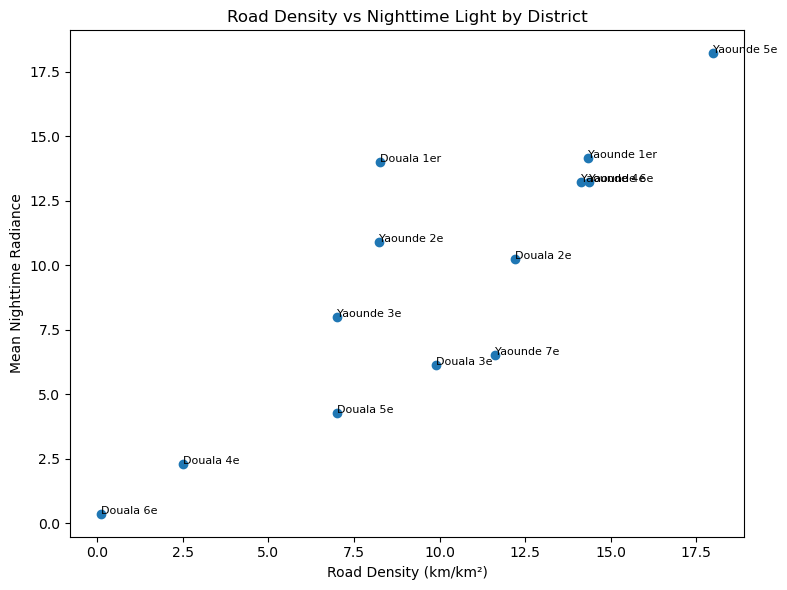

In [10]:
import matplotlib.pyplot as plt

viirs = pd.read_csv("../data/processed/viirs_nightlight_2025.csv")
combined = result.merge(viirs, on='district_name')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(combined['road_density_km_per_sqkm'], combined['mean_radiance'])
for i, row in combined.iterrows():
    ax.annotate(row['district_name'], (row['road_density_km_per_sqkm'], row['mean_radiance']), fontsize=8)
ax.set_xlabel('Road Density (km/km²)')
ax.set_ylabel('Mean Nighttime Radiance')
ax.set_title('Road Density vs Nighttime Light by District')
plt.tight_layout()
plt.show()

In [11]:
import geopandas as gpd
import pandas as pd

# waterways 레이어 확인
import pyogrio
layers = pyogrio.list_layers("../data/raw/waterways.gpkg")
print("레이어:", layers)

# 불러오기
waterways_raw = gpd.read_file("../data/raw/waterways.gpkg")
print(f"\n전체 수계 수: {len(waterways_raw)}")
print("\n컬럼:", waterways_raw.columns.tolist())

레이어: [['waterways' 'Unknown']]

전체 수계 수: 36991

컬럼: ['id', 'name', 'name_en', 'name_fr', 'waterway', 'covered', 'width', 'depth', 'layer', 'blockage', 'tunnel', 'natural_class', 'water', 'source', 'adm0_pcode', 'adm0_name', 'adm1_pcode', 'adm1_name', 'adm2_pcode', 'adm2_name', 'adm3_pcode', 'adm3_name', 'adm4_pcode', 'adm4_name', 'name_latin', 'geometry']


In [12]:
# 필터링
waterways_target = waterways_raw[waterways_raw['adm2_pcode'].isin(['CM002007', 'CM005004'])].copy()
print(f"두알라/야운데 수계 수: {len(waterways_target)}")

# waterway 타입 분포
print("\nwaterway 타입:")
print(waterways_target['waterway'].value_counts())

# 구역별 분포
print("\n구역별 분포:")
print(waterways_target['adm3_name'].value_counts())

# null 체크
print("\nNull 값:")
print(waterways_target[['waterway', 'adm3_name']].isnull().sum())

두알라/야운데 수계 수: 12147

waterway 타입:
waterway
drain        7461
stream       2098
ditch        1688
river         152
canal          23
dam             3
waterfall       1
Name: count, dtype: int64

구역별 분포:
adm3_name
Douala 5e      2622
Douala 3e      2314
Douala 1er     1797
Douala 4e      1408
Douala 2e       936
Yaounde 1er     744
Yaounde 4e      638
Yaounde 3e      467
Yaounde 7e      412
Yaounde 6e      303
Yaounde 5e      293
Douala 6e       166
Yaounde 2e       47
Name: count, dtype: int64

Null 값:
waterway     721
adm3_name      0
dtype: int64


In [13]:
# river + stream만 필터링
natural_water = waterways_target[waterways_target['waterway'].isin(['river', 'stream'])].copy()
print(f"river + stream 수: {len(natural_water)}")

# UTM Zone 32N으로 변환 (미터 단위 길이 계산)
natural_water = natural_water.to_crs(epsg=32632)
natural_water['length_m'] = natural_water.geometry.length

print(natural_water['length_m'].describe())

river + stream 수: 2250
count     2250.000000
mean       432.828121
std       1442.679151
min          0.206124
25%         29.350126
50%         82.619675
75%        316.404045
max      46273.948192
Name: length_m, dtype: float64


In [14]:
# 구역별 합산
water_length = natural_water.groupby(['adm3_name', 'adm3_pcode'])['length_m'].sum().reset_index()
water_length.columns = ['district_name', 'district_pcode', 'total_water_length_m']
water_length['total_water_length_km'] = water_length['total_water_length_m'] / 1000

# 구역 면적과 합치기
districts = gpd.read_file("../data/processed/douala_yaounde_districts.geojson")
merged = water_length.merge(districts[['district_pcode', 'city', 'area_sqkm']], on='district_pcode')
merged['water_density_km_per_sqkm'] = merged['total_water_length_km'] / merged['area_sqkm']

result_water = merged[['district_name', 'city', 'area_sqkm', 'total_water_length_km', 'water_density_km_per_sqkm']]
print(result_water.sort_values('water_density_km_per_sqkm', ascending=False).to_string(index=False))

district_name    city  area_sqkm  total_water_length_km  water_density_km_per_sqkm
    Douala 2e  Douala  16.122946              24.027357                   1.490258
   Yaounde 6e Yaounde  22.155349              29.659083                   1.338687
   Yaounde 7e Yaounde  35.308215              46.439080                   1.315249
   Yaounde 5e Yaounde  25.851188              32.867140                   1.271398
   Yaounde 4e Yaounde  58.799044              68.584708                   1.166426
  Yaounde 1er Yaounde  56.179165              59.903624                   1.066296
    Douala 4e  Douala 204.001531             203.555749                   0.997815
   Douala 1er  Douala  32.059804              27.528821                   0.858671
   Yaounde 2e Yaounde  22.955702              19.637694                   0.855460
    Douala 3e  Douala 167.403239             140.479208                   0.839167
   Yaounde 3e Yaounde  68.159097              37.451635                   0.549474
    

In [15]:
result_water.to_csv("../data/processed/water_density_2026.csv", index=False)
print("저장 완료!")

저장 완료!
